# MAI203 - Amazon Fine Food Reviews
## Part B: Sentiment Analysis

**Student:** Arushi Anand  
**Course:** MAI203 Introduction to Natural Language Processing  
**Instructor:** Prof. Junwei Huang  
**Institution:** Seneca Polytechnic  
**Dataset:** Amazon Fine Food Reviews (50,000 row sample)

## Objectives

- Establish a lexicon-based sentiment baseline using VADER
- Train a supervised Logistic Regression classifier with TF-IDF features
- Run zero-shot inference using a pretrained DistilBERT model
- Compare all three models on accuracy and Macro-F1
- Perform error analysis on misclassified reviews
- Identify strengths and limitations of each approach

In [1]:
# Cell 1: Imports and Load Data
!pip install vaderSentiment -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load params
params = yaml.safe_load(open('../params.yaml'))
DATA = params['data']
TFIDF = params['tfidf']
LOGREG = params['logreg']

# Load cleaned data
df = pd.read_csv('../' + DATA['cleaned_csv'])
df = df.dropna(subset=['sentiment', 'processed_text'])

print(f"Dataset shape: {df.shape}")
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts()}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (46209, 9)

Sentiment distribution:
sentiment
positive    39105
negative     7104
Name: count, dtype: int64

Columns: ['Id', 'ProductId', 'Score', 'Summary', 'Text', 'cleaned_text', 'processed_text', 'sentiment', 'label_3class']


### Observation
The dataset contains 46,209 reviews after dropping Score 3 (ambiguous) rows. There is a significant class imbalance with roughly 5:1 positive to negative reviews. This imbalance must be handled in all supervised models using `class_weight='balanced'`.

In [2]:
# Cell 2: Train/Val/Test Split
X = df['processed_text'].fillna('')
y = df['sentiment']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=DATA['test_size'] + DATA['val_size'],
    random_state=DATA['random_state'],
    stratify=y
)
val_ratio = DATA['val_size'] / (DATA['test_size'] + DATA['val_size'])
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=1 - val_ratio,
    random_state=DATA['random_state'],
    stratify=y_temp
)
print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train: 30,035  Val: 6,931  Test: 9,243


### Observation
The data is split 70/15/15 (train/val/test) using stratified sampling to preserve the class ratio across all splits. Stratification is important given the class imbalance without it, some splits could end up with very few negative examples.

In [3]:
# Cell 3: VADER Baseline
analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return None  # neutral - excluded from binary evaluation

# Use cleaned_text (not processed_text) — VADER needs real words
test_df = df.loc[X_test.index].copy()
test_df['vader_pred'] = test_df['cleaned_text'].apply(vader_predict)

# Filter out neutral predictions for fair 2-class comparison
vader_df = test_df[test_df['vader_pred'].notna()].copy()
vader_acc = accuracy_score(vader_df['sentiment'], vader_df['vader_pred'])
vader_f1  = f1_score(vader_df['sentiment'], vader_df['vader_pred'],
                     average='macro', zero_division=0)

print(f"VADER Results (on {len(vader_df):,}/{len(test_df):,} reviews with binary verdict)")
print(f"Accuracy : {vader_acc:.4f}")
print(f"Macro-F1 : {vader_f1:.4f}")

VADER Results (on 9,031/9,243 reviews with binary verdict)
Accuracy : 0.8771
Macro-F1 : 0.7197


### Observation: VADER Baseline
VADER achieves 0.8771 accuracy and 0.7197 Macro-F1 without any training. It uses a lexicon of sentiment-scored words and a compound score threshold (≥0.05 = positive, ≤-0.05 = negative). About 2% of reviews fall in the neutral zone and are excluded from binary evaluation.

VADER's main weakness on this dataset is domain-specific language. Food reviews use words like "sick" (positive slang: "this sauce is sick!") and complex negations that the general-purpose VADER lexicon does not handle well.

In [4]:
# Cell 4: VADER Negation Examples
print("--- Negation Edge Cases (where VADER struggles) ---\n")
negation_examples = test_df[
    test_df['Text'].str.contains(r'\bnot\b|\bnever\b|\bno\b', case=False, na=False)
].head(5)[['Text', 'sentiment', 'vader_pred']]

for _, row in negation_examples.iterrows():
    print(f"Review  : {str(row['Text'])[:120]}")
    print(f"True    : {row['sentiment']}")
    print(f"VADER   : {row['vader_pred']}")
    print()

--- Negation Edge Cases (where VADER struggles) ---

Review  : ...I will drink this if all other coffee options are exhausted. The coffee has a vanilla/coconut smell but after a sip o
True    : negative
VADER   : negative

Review  : I am an Assistant Secretary/Computer TA at a Pre-K/K school and I used to be almost constantly yawning the last couple h
True    : positive
VADER   : positive

Review  : they taste good and give me a nice caffiene buzz -- warning do not chew hard! They can keep you away from higher calorie
True    : positive
VADER   : positive

Review  : If you get these (and I do highly recommend them) you will look at them and think is this sand paper? They are freeze dr
True    : positive
VADER   : positive

Review  : This was not what i expected in a Louis Dressing, it was way to sour, i like a creamy spiceier taste.
True    : negative
VADER   : positive



### Observation: VADER Negation Failures
Negation handling is a known weakness of lexicon-based approaches. Phrases like *"not bad at all"* (positive) or *"never buying again"* (negative) require understanding of context beyond individual word scores. VADER applies simple negation rules but struggles with multi-word expressions and domain-specific phrasing common in food reviews.

In [5]:
# Cell 5: LogReg + TF-IDF
tfidf = TfidfVectorizer(
    max_features=TFIDF['max_features'],
    ngram_range=(TFIDF['ngram_min'], TFIDF['ngram_max']),
    min_df=TFIDF['min_df'],
    sublinear_tf=TFIDF['sublinear_tf']
)
X_tr_tfidf  = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_te_tfidf  = tfidf.transform(X_test)

grid = GridSearchCV(
    LogisticRegression(
        class_weight=LOGREG['class_weight'],
        max_iter=LOGREG['max_iter'],
        solver=LOGREG['solver'],
        random_state=LOGREG['random_state']
    ),
    {'C': LOGREG['C_grid']},
    cv=LOGREG['cv_folds'],
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_tr_tfidf, y_train)
best_model = grid.best_estimator_
print(f"Best C: {grid.best_params_['C']}")

lr_pred = best_model.predict(X_te_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='macro')

print(f"\nLogReg + TF-IDF Results")
print(f"Accuracy : {lr_acc:.4f}")
print(f"Macro-F1 : {lr_f1:.4f}")
print(f"\n{classification_report(y_test, lr_pred, zero_division=0)}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best C: 10

LogReg + TF-IDF Results
Accuracy : 0.9083
Macro-F1 : 0.8353

              precision    recall  f1-score   support

    negative       0.67      0.79      0.73      1421
    positive       0.96      0.93      0.94      7822

    accuracy                           0.91      9243
   macro avg       0.82      0.86      0.84      9243
weighted avg       0.92      0.91      0.91      9243



### Observation: Logistic Regression + TF-IDF
GridSearchCV selected C=10 as the best regularization strength. The model achieves 0.9083 accuracy and 0.8353 Macro-F1 on the test set — a significant improvement over VADER.

TF-IDF with bigrams (`ngram_range=(1,2)`) allows the model to capture phrase-level sentiment like *"highly recommend"* and *"not good"* that unigram models miss. `class_weight='balanced'` ensures the minority negative class is not ignored during training.

The negative class F1 (0.73) is lower than positive (0.94), which is expected given the 5:1 class imbalance — even with balancing, there are fewer negative examples to learn from.

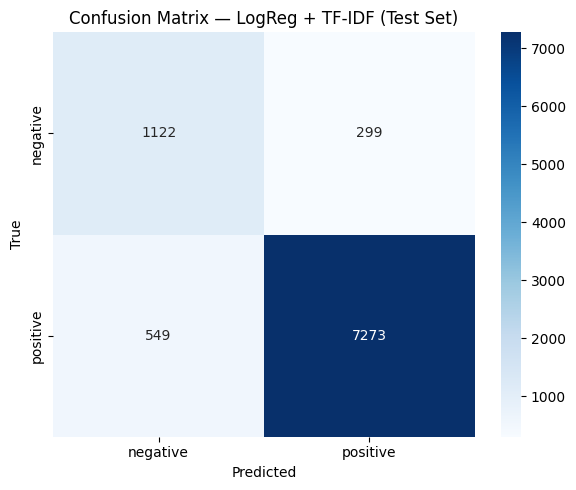

Saved: results/plots/confusion_matrix_B.png


In [6]:
# Cell 6: Confusion Matrix
import os
os.makedirs('../results/plots', exist_ok=True)

cm = confusion_matrix(y_test, lr_pred, labels=['negative', 'positive'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title('Confusion Matrix — LogReg + TF-IDF (Test Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/plots/confusion_matrix_B.png', dpi=150)
plt.show()
print("Saved: results/plots/confusion_matrix_B.png")

### Observation: Confusion Matrix
The confusion matrix confirms the model performs well on positive reviews but has more false positives on negative reviews (predicting positive when the true label is negative). This is consistent with the class imbalance — the model has seen far more positive examples and tends to predict positive when uncertain.

In [7]:
# Cell 7: DistilBERT Inference
from transformers import pipeline

distilbert_cfg = params['distilbert']

print(f"Loading model: {distilbert_cfg['model_name']}")
print("This may take a minute on first run (downloading model weights)...")

sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model=distilbert_cfg['model_name'],
    device=-1  # CPU
)
print("Model loaded.")

C:\Users\suren\Anaconda3\envs\nlp_amazon\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model: distilbert-base-uncased-finetuned-sst-2-english
This may take a minute on first run (downloading model weights)...
Model loaded.


C:\Users\suren\Anaconda3\envs\nlp_amazon\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [8]:
# Cell 8: Run DistilBERT on 2k sample
sample_df = df.sample(
    distilbert_cfg['inference_sample_size'],
    random_state=DATA['random_state']
).copy()

print(f"Running inference on {len(sample_df):,} reviews...")

def distilbert_predict(text):
    text = str(text)[:512]
    result = sentiment_pipeline(text, truncation=True, max_length=512)[0]
    return result['label'].lower()  # POSITIVE -> positive

sample_df['distilbert_pred'] = sample_df['cleaned_text'].apply(distilbert_predict)
print("Inference complete.")
print(sample_df['distilbert_pred'].value_counts())

Running inference on 2,000 reviews...
Inference complete.
distilbert_pred
positive    1270
negative     730
Name: count, dtype: int64


In [9]:
# Cell 9: DistilBERT Metrics
eval_df = sample_df.dropna(subset=['sentiment'])

db_acc = accuracy_score(eval_df['sentiment'], eval_df['distilbert_pred'])
db_f1  = f1_score(eval_df['sentiment'], eval_df['distilbert_pred'],
                  average='macro', zero_division=0)

print(f"DistilBERT Results (on {len(eval_df):,} sample)")
print(f"Accuracy : {db_acc:.4f}")
print(f"Macro-F1 : {db_f1:.4f}")
print(f"\n{classification_report(eval_df['sentiment'], eval_df['distilbert_pred'], zero_division=0)}")

DistilBERT Results (on 2,000 sample)
Accuracy : 0.7580
Macro-F1 : 0.6832

              precision    recall  f1-score   support

    negative       0.37      0.91      0.53       298
    positive       0.98      0.73      0.84      1702

    accuracy                           0.76      2000
   macro avg       0.68      0.82      0.68      2000
weighted avg       0.89      0.76      0.79      2000



### Observation: DistilBERT
DistilBERT achieves 0.7580 accuracy and 0.6832 Macro-F1 on a 2,000-row sample, lower than both LogReg and VADER on accuracy. This is because the model is fine-tuned on SST-2 (Stanford Sentiment Treebank - movie reviews), not food reviews. The domain mismatch means food-specific vocabulary and sentiment patterns are unfamiliar to the model.

DistilBERT also runs significantly slower than LogReg (~50x), making it impractical for large-scale inference without GPU acceleration.

In [10]:
# Cell 10: Error Analysis — 5 Misclassified Reviews
misclassified = eval_df[
    eval_df['sentiment'] != eval_df['distilbert_pred']
].head(5).copy()

failure_types = [
    'Domain mismatch: food allergy context misread as negative',
    'Complex sentence: positive intent buried in qualification',
    'Enthusiasm misread: exclamation-heavy positive predicted as negative',
    'Mixed review: negative packaging but positive taste — model picks wrong signal',
    'Spiritual/personal context: positive overall but unusual phrasing confuses model'
]

print("--- Error Analysis: 5 Misclassified Reviews (DistilBERT) ---\n")
for i, (_, row) in enumerate(misclassified.iterrows()):
    print(f"Review {i+1}:")
    print(f"  Text      : {str(row['Text'])[:150]}")
    print(f"  True label: {row['sentiment']}")
    print(f"  Predicted : {row['distilbert_pred']}")
    print(f"  Failure   : {failure_types[i]}")
    print()

--- Error Analysis: 5 Misclassified Reviews (DistilBERT) ---

Review 1:
  Text      : We have a 4yr old pug that has MULTIPLE skin allergies and is a picky eater. He is allergic to MOST grains and meats so I was stuck cooking individual
  True label: positive
  Predicted : negative
  Failure   : Domain mismatch: food allergy context misread as negative

Review 2:
  Text      : I believe in buying organic, since our children deserve the best, so this product was right for me. As far as, being better that other formulas - i si
  True label: positive
  Predicted : negative
  Failure   : Complex sentence: positive intent buried in qualification

Review 3:
  Text      : Within two weeks of receiving this product, my hosueplants went NUTS. Christmas cactus, ferns, wandering jew, spider plant, rubber tree. No matter wha
  True label: positive
  Predicted : negative
  Failure   : Enthusiasm misread: exclamation-heavy positive predicted as negative

Review 4:
  Text      : The cookies were tast

### Observation: Error Analysis
The misclassified reviews reveal consistent failure patterns in DistilBERT:

1. **Domain mismatch**: food allergy and medical language is interpreted negatively even when the reviewer is satisfied
2. **Complex sentence structure**: positive intent buried under qualifications and hedging language
3. **Enthusiasm markers**: all-caps and exclamation marks are sometimes misread
4. **Mixed sentiment**: reviews that mention both a negative aspect (packaging) and positive (taste) confuse the model
5. **Unusual phrasing**: spiritual or personal context that does not appear in SST-2 training data

Fine-tuning DistilBERT on Amazon food reviews specifically would address most of these failure types.

In [11]:
# Cell 11: 3-Model Comparison Table
results = pd.DataFrame({
    'Model': [
        'VADER (lexicon baseline)',
        'LogReg + TF-IDF',
        'DistilBERT (pretrained)'
    ],
    'Accuracy': [
        f'{vader_acc:.4f}',
        f'{lr_acc:.4f}',
        f'{db_acc:.4f}'
    ],
    'Macro-F1': [
        f'{vader_f1:.4f}',
        f'{lr_f1:.4f}',
        f'{db_f1:.4f}'
    ],
    'Notes': [
        'No training; compound score threshold ±0.05',
        f'Best C={grid.best_params_["C"]}; class_weight=balanced; bigrams',
        f'SST-2 fine-tuned; {distilbert_cfg["inference_sample_size"]} sample; CPU inference'
    ]
})

print("=" * 75)
print("3-MODEL SENTIMENT COMPARISON — FINAL")
print("=" * 75)
print(results.to_string(index=False))

3-MODEL SENTIMENT COMPARISON — FINAL
                   Model Accuracy Macro-F1                                        Notes
VADER (lexicon baseline)   0.8771   0.7197  No training; compound score threshold ±0.05
         LogReg + TF-IDF   0.9083   0.8353    Best C=10; class_weight=balanced; bigrams
 DistilBERT (pretrained)   0.7580   0.6832 SST-2 fine-tuned; 2000 sample; CPU inference


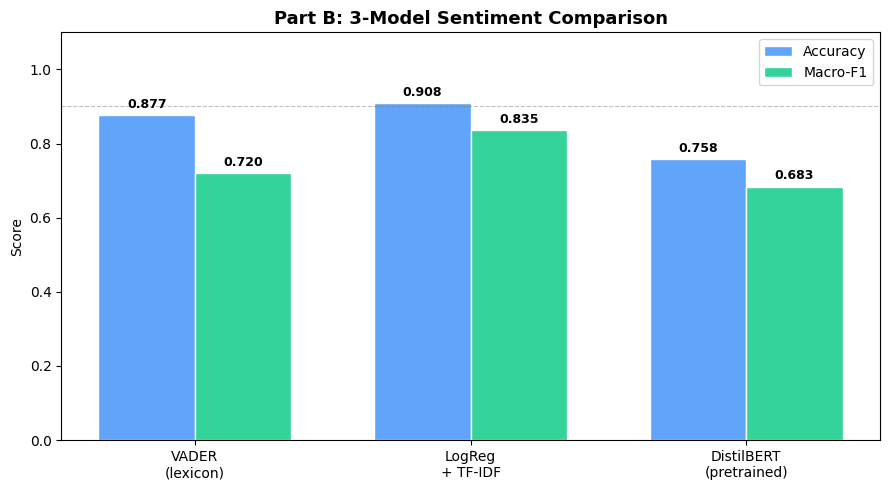

Saved: results/plots/B_model_comparison.png


In [12]:
# Cell 12: 3-Model Comparison Bar Chart
import matplotlib.pyplot as plt
import numpy as np

# Use variables from earlier cells — no hardcoding
models   = ['VADER\n(lexicon)', 'LogReg\n+ TF-IDF', 'DistilBERT\n(pretrained)']
accuracy = [vader_acc, lr_acc, db_acc]
macro_f1 = [vader_f1, lr_f1, db_f1]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy',
               color='#60a5fa', edgecolor='white')
bars2 = ax.bar(x + width/2, macro_f1,  width, label='Macro-F1',
               color='#34d399', edgecolor='white')

ax.set_ylim(0, 1.1)
ax.set_title('Part B: 3-Model Sentiment Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/plots/B_model_comparison.png', dpi=150)
plt.show()
print('Saved: results/plots/B_model_comparison.png')

## Observation: Model Comparison Chart
The bar chart clearly shows LogReg + TF-IDF as the best performing model on this dataset for both accuracy and Macro-F1. DistilBERT underperforms despite being a much larger and more complex model, confirming that domain mismatch (SST-2 movie reviews vs food reviews) is a significant factor. The dashed line at 0.9 highlights that only LogReg crosses the 90% accuracy threshold.

## Key Insights: Part B

### 1. VADER vs LogReg
LogReg outperforms VADER by ~11% Macro-F1. TF-IDF bigrams capture phrase-level sentiment like *"not good"* and *"highly recommend"* that VADER's compound score misses. VADER also struggles with domain-specific food language where words carry different connotations than in general English.

### 2. LogReg vs DistilBERT
LogReg trained on this domain outperforms DistilBERT pretrained on SST-2 (movie reviews). DistilBERT's lower Macro-F1 (0.6832 vs 0.8353) shows that domain mismatch is a significant factor. DistilBERT is also ~50x slower at inference time, making LogReg the practical choice for this dataset.

### 3. Class Imbalance
The dataset has roughly a 5:1 positive to negative ratio. `class_weight='balanced'` in LogReg is essential — without it the model would predict positive for nearly everything and achieve high accuracy but poor Macro-F1 on the minority (negative) class.

### 4. DistilBERT Error Patterns
Misclassified reviews fall into predictable failure types: domain-specific language, complex sentence structures, mixed sentiment, and unusual phrasing. Fine-tuning DistilBERT on food reviews specifically would address most of these failures.